# Employee Attrition ML Model Training

**Dataset:** IBM HR Analytics — via `workspace.gold.gold_ml_features`

**Models:** Random Forest, Logistic Regression, Gradient Boosted Trees

**Tracking:** MLflow experiment tracking + model registry

**Target:** `attrition` (1=left, 0=stayed) — ~16% positive class

---

### Pipeline
1. Load gold features from Delta table
2. Train/test split (stratified, 80/20)
3. Train 3 models with class balancing
4. Evaluate: AUC-ROC, Precision, Recall, F1
5. Feature importance analysis
6. Log everything to MLflow
7. Register best model

## 0. Setup & Imports

In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, f1_score,
    accuracy_score, precision_score, recall_score,
    average_precision_score
)
from sklearn.inspection import permutation_importance

# MLflow
import mlflow
import mlflow.sklearn

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
pd.set_option("display.max_columns", 100)

print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Run started: 2026-02-13 16:33:54


## 1. MLflow Setup

Configure MLflow to track experiments in Databricks.

In [0]:
# --- Spark Connect + MLflow Monkey Patch ---
# Databricks Community Edition uses Spark Connect, which doesn't support
# spark.mlflow.modelRegistryUri config. Patch it before any MLflow calls.

import mlflow
from mlflow.tracking._model_registry import utils as registry_utils

# Disable the function that tries to read Spark config (causes GRPC error)
registry_utils._get_registry_uri_from_spark_session = lambda: None

# Use Unity Catalog model registry (legacy workspace registry is disabled)
mlflow.set_registry_uri("databricks-uc")

# --- MLflow Configuration ---
EXPERIMENT_NAME = "/Users/mahmoudgribej7@gmail.com/employee-attrition-ibm-hr"

mlflow.set_experiment(EXPERIMENT_NAME)
mlflow.sklearn.autolog(disable=True)  # We'll log manually for full control

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"MLflow registry URI: {mlflow.get_registry_uri()}")
print(f"Experiment: {EXPERIMENT_NAME}")
print("Spark Connect patch applied ✅")

MLflow tracking URI: databricks
MLflow registry URI: databricks-uc
Experiment: /Users/mahmoudgribej7@gmail.com/employee-attrition-ibm-hr
Spark Connect patch applied ✅


## 2. Load Data from Gold Layer

In [0]:
# --- Load gold ML features ---
df = spark.table("workspace.gold.gold_ml_features").toPandas()

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nTarget distribution:")
print(df["attrition"].value_counts())
print(f"\nAttrition rate: {df['attrition'].mean() * 100:.1f}%")
print(f"\nNull counts: {df.isnull().sum().sum()}")
df.head()

Shape: 1470 rows × 78 columns

Target distribution:
0    1233
1     237
Name: attrition, dtype: int64

Attrition rate: 16.1%

Null counts: 0


,attrition,age,distance_from_home,education,job_level,monthly_income,num_companies_worked,percent_salary_hike,stock_option_level,total_working_years,training_times_last_year,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager,environment_satisfaction,job_satisfaction,job_involvement,performance_rating,relationship_satisfaction,work_life_balance,gender,overtime,business_travel_encoded,income_per_year,income_per_age,income_per_company_year,promo_stagnation,role_tenure_ratio,manager_stability,career_ratio,company_loyalty_ratio,avg_satisfaction,overall_wellbeing,is_early_career,is_new_hire,long_time_since_promo,is_young_employee,is_entry_level,no_stock_options,low_env_satisfaction,low_job_satisfaction,poor_work_life_balance,overtime_sales_rep,overtime_single,entry_no_equity,distance_overtime_interaction,dept_avg_income,dept_avg_age,dept_avg_experience,dept_headcount,dept_overtime_rate,role_avg_income,role_avg_experience,role_headcount,income_vs_dept_avg,age_vs_dept_avg,dept_sales,dept_research_dev,dept_hr,role_sales_executive,role_research_scientist,role_lab_technician,role_manufacturing_director,role_healthcare_rep,role_manager,role_sales_rep,role_research_director,role_hr,marital_single,marital_married,marital_divorced,edu_life_sciences,edu_medical,edu_marketing,edu_technical,edu_other,edu_hr
0,1,41,1,2,2,5993,8,11,0,8,0,6,4,0,5,2,4,3,3,1,1,0,1,1,665.888889,146.170732,856.142857,0.000000,0.571429,0.714286,0.195122,0.666667,2.333333,2.000000,0,0,0,0,0,1,1,0,1,0,1,0,1,6959.172646,36.542601,11.105381,446,0.286996,6924.279141,11.101227,326,0.861166,1.121978,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
1,0,49,8,1,2,5130,1,23,1,10,3,10,7,1,7,3,2,2,4,4,3,1,0,2,466.363636,104.693878,466.363636,0.090909,0.636364,0.636364,0.204082,0.909091,3.000000,3.000000,0,0,0,0,0,0,0,1,0,0,0,0,0,6281.252862,37.042664,11.342352,961,0.281998,3239.972603,7.715753,292,0.816716,1.322799,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,1,37,2,2,1,2090,6,15,0,7,3,0,0,0,0,4,3,2,3,2,3,1,1,1,261.250000,56.486486,2090.000000,0.000000,0.000000,0.000000,0.189189,0.000000,3.000000,3.000000,0,1,0,0,1,1,0,0,0,0,1,1,2,6281.252862,37.042664,11.342352,961,0.281998,3237.169884,7.656371,259,0.332736,0.998848,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
3,0,33,3,4,1,2909,1,11,0,8,3,8,7,3,0,4,3,3,3,3,3,0,1,2,323.222222,88.151515,323.222222,0.333333,0.777778,0.000000,0.242424,0.888889,3.333333,3.250000,0,0,0,0,1,1,0,0,0,0,0,1,3,6281.252862,37.042664,11.342352,961,0.281998,3239.972603,7.715753,292,0.463124,0.890865,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
4,0,27,2,1,1,3468,9,12,1,6,3,2,2,2,2,1,2,3,3,4,3,1,0,1,495.428571,128.444444,1156.000000,0.666667,0.666667,0.666667,0.222222,0.285714,2.333333,2.500000,0,1,0,1,1,0,1,1,0,0,0,0,0,6281.252862,37.042664,11.342352,961,0.281998,3237.169884,7.656371,259,0.552119,0.728889,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0


## 3. Feature Selection & Train/Test Split

In [0]:
# --- Drop non-numeric columns that slipped through ---
# Gold layer has string columns (department, job_role, etc.) alongside their one-hot versions
# We only want numeric columns for ML

non_feature_cols = ["attrition"]  # target — separate it
string_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"String columns to exclude from features: {string_cols}")

# Feature matrix and target
feature_cols = [c for c in df.columns if c not in non_feature_cols + string_cols]
X = df[feature_cols]
y = df["attrition"]

print(f"\nFeature matrix: {X.shape[0]} rows × {X.shape[1]} features")
print(f"Target: {y.shape[0]} values")
print(f"\nFeature columns ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:3d}. {col}")

String columns to exclude from features: ['avg_satisfaction', 'overall_wellbeing']

Feature matrix: 1470 rows × 75 features
Target: 1470 values

Feature columns (75):
    1. age
    2. distance_from_home
    3. education
    4. job_level
    5. monthly_income
    6. num_companies_worked
    7. percent_salary_hike
    8. stock_option_level
    9. total_working_years
   10. training_times_last_year
   11. years_at_company
   12. years_in_current_role
   13. years_since_last_promotion
   14. years_with_curr_manager
   15. environment_satisfaction
   16. job_satisfaction
   17. job_involvement
   18. performance_rating
   19. relationship_satisfaction
   20. work_life_balance
   21. gender
   22. overtime
   23. business_travel_encoded
   24. income_per_year
   25. income_per_age
   26. income_per_company_year
   27. promo_stagnation
   28. role_tenure_ratio
   29. manager_stability
   30. career_ratio
   31. company_loyalty_ratio
   32. is_early_career
   33. is_new_hire
   34. long_time_

In [0]:
# --- Handle any remaining nulls from division-by-zero in engineered features ---
null_counts = X.isnull().sum()
null_cols = null_counts[null_counts > 0]

if len(null_cols) > 0:
    print(f"Columns with nulls (from division operations):")
    print(null_cols)
    print(f"\nFilling with 0 (safe for ratio features where denominator was 0)")
    X = X.fillna(0)
else:
    print("No nulls detected — clean feature matrix")

No nulls detected — clean feature matrix


In [0]:
# --- Stratified train/test split ---
# Stratified ensures both sets have ~16% attrition rate

TEST_SIZE = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train set: {X_train.shape[0]} rows ({y_train.mean()*100:.1f}% attrition)")
print(f"Test set:  {X_test.shape[0]} rows ({y_test.mean()*100:.1f}% attrition)")
print(f"\nClass distribution preserved: ✅")

Train set: 1176 rows (16.2% attrition)
Test set:  294 rows (16.0% attrition)

Class distribution preserved: ✅


In [0]:
# --- Feature scaling (for Logistic Regression) ---
# Tree models don't need scaling, but LR does

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep as DataFrames for feature importance later
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_cols, index=X_test.index)

print(f"Scaled features: mean ≈ {X_train_scaled.mean():.4f}, std ≈ {X_train_scaled.std():.4f}")

Scaled features: mean ≈ -0.0000, std ≈ 1.0000


## 4. Define Models & Evaluation Framework

In [0]:
# --- Model definitions ---
# All use class_weight='balanced' to handle 16% minority class

models = {
    "Random Forest": {
        "model": RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            min_samples_split=10,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "use_scaled": False,  # Trees don't need scaling
    },
    "Logistic Regression": {
        "model": LogisticRegression(
            C=0.1,
            penalty="l2",
            class_weight="balanced",
            max_iter=1000,
            random_state=RANDOM_STATE,
            solver="lbfgs"
        ),
        "use_scaled": True,  # LR needs scaling
    },
    "Gradient Boosted Trees": {
        "model": GradientBoostingClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            min_samples_split=10,
            min_samples_leaf=5,
            subsample=0.8,
            random_state=RANDOM_STATE
        ),
        "use_scaled": False,  # Trees don't need scaling
    },
}

print(f"Models to train: {len(models)}")
for name, cfg in models.items():
    print(f"  • {name} (scaled={cfg['use_scaled']})")

Models to train: 3
  • Random Forest (scaled=False)
  • Logistic Regression (scaled=True)
  • Gradient Boosted Trees (scaled=False)


In [0]:
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """
    Train, evaluate, and return comprehensive metrics for a classifier.
    """
    # Train
    model.fit(X_tr, y_tr)
    
    # Predict
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    # Cross-validation (5-fold stratified on training set)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="roc_auc")
    
    # Metrics
    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        "auc_roc": roc_auc_score(y_te, y_proba),
        "avg_precision": average_precision_score(y_te, y_proba),
        "cv_auc_mean": cv_scores.mean(),
        "cv_auc_std": cv_scores.std(),
    }
    
    # Store predictions for plotting
    metrics["y_pred"] = y_pred
    metrics["y_proba"] = y_proba
    metrics["cv_scores"] = cv_scores
    
    return metrics


print("Evaluation function ready")

Evaluation function ready


## 5. Train All Models with MLflow Tracking

In [0]:
# --- Train and evaluate all models ---
results = {}

for name, cfg in models.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print(f"{'='*60}")
    
    # Select scaled or unscaled features
    if cfg["use_scaled"]:
        X_tr, X_te = X_train_scaled_df, X_test_scaled_df
    else:
        X_tr, X_te = X_train, X_test
    
    # Start MLflow run
    with mlflow.start_run(run_name=name) as run:
        # Train & evaluate
        metrics = evaluate_model(cfg["model"], X_tr, X_te, y_train, y_test, name)
        results[name] = metrics
        
        # Log parameters
        mlflow.log_param("model_type", name)
        mlflow.log_param("n_features", X_tr.shape[1])
        mlflow.log_param("train_size", X_tr.shape[0])
        mlflow.log_param("test_size", X_te.shape[0])
        mlflow.log_param("class_weight", "balanced")
        mlflow.log_param("feature_scaling", cfg["use_scaled"])
        
        # Log model-specific hyperparameters
        model_params = cfg["model"].get_params()
        for param_name, param_value in model_params.items():
            try:
                mlflow.log_param(param_name, param_value)
            except Exception:
                pass  # Skip non-serializable params
        
        # Log metrics
        mlflow.log_metric("accuracy", metrics["accuracy"])
        mlflow.log_metric("precision", metrics["precision"])
        mlflow.log_metric("recall", metrics["recall"])
        mlflow.log_metric("f1_score", metrics["f1"])
        mlflow.log_metric("auc_roc", metrics["auc_roc"])
        mlflow.log_metric("avg_precision", metrics["avg_precision"])
        mlflow.log_metric("cv_auc_mean", metrics["cv_auc_mean"])
        mlflow.log_metric("cv_auc_std", metrics["cv_auc_std"])
        
        # Log model artifact
        mlflow.sklearn.log_model(cfg["model"], artifact_path="model")
        
        # Log feature names
        mlflow.log_text(",".join(feature_cols), "feature_columns.txt")
        
        # Print summary
        print(f"\n  AUC-ROC:       {metrics['auc_roc']:.4f}")
        print(f"  F1 Score:      {metrics['f1']:.4f}")
        print(f"  Precision:     {metrics['precision']:.4f}")
        print(f"  Recall:        {metrics['recall']:.4f}")
        print(f"  Accuracy:      {metrics['accuracy']:.4f}")
        print(f"  CV AUC:        {metrics['cv_auc_mean']:.4f} ± {metrics['cv_auc_std']:.4f}")
        print(f"  Avg Precision: {metrics['avg_precision']:.4f}")
        print(f"  MLflow Run ID: {run.info.run_id}")

print(f"\n\n{'='*60}")
print("All models trained and logged to MLflow ✅")
print(f"{'='*60}")


Training: Random Forest


2026/02/13 16:34:03 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.



  AUC-ROC:       0.7840
  F1 Score:      0.4000
  Precision:     0.4474
  Recall:        0.3617
  Accuracy:      0.8265
  CV AUC:        0.8084 ± 0.0241
  Avg Precision: 0.4173
  MLflow Run ID: 85dc93d73dbb4a67ad5273c5e9230b0b

Training: Logistic Regression


2026/02/13 16:34:07 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.



  AUC-ROC:       0.8387
  F1 Score:      0.4923
  Precision:     0.3855
  Recall:        0.6809
  Accuracy:      0.7755
  CV AUC:        0.8405 ± 0.0336
  Avg Precision: 0.5739
  MLflow Run ID: 2d6fb7db0c3b4e12bc3f7b0a5b762d61

Training: Gradient Boosted Trees


2026/02/13 16:34:20 WARNING mlflow.models.model: Model logged without a signature. Signatures will be required for upcoming model registry features as they validate model inputs and denote the expected schema of model outputs. Please visit https://www.mlflow.org/docs/2.11.4/models.html#set-signature-on-logged-model for instructions on setting a model signature on your logged model.



  AUC-ROC:       0.7906
  F1 Score:      0.3881
  Precision:     0.6500
  Recall:        0.2766
  Accuracy:      0.8605
  CV AUC:        0.8122 ± 0.0259
  Avg Precision: 0.4756
  MLflow Run ID: 9f5546fc01ee460eb175a86d608472a3


All models trained and logged to MLflow ✅


## 6. Model Comparison

In [0]:
# --- Comparison table ---
comparison_df = pd.DataFrame([
    {
        "Model": r["model_name"],
        "AUC-ROC": r["auc_roc"],
        "F1 Score": r["f1"],
        "Precision": r["precision"],
        "Recall": r["recall"],
        "Accuracy": r["accuracy"],
        "CV AUC (mean)": r["cv_auc_mean"],
        "CV AUC (std)": r["cv_auc_std"],
        "Avg Precision": r["avg_precision"],
    }
    for r in results.values()
]).sort_values("AUC-ROC", ascending=False)

print("Model Comparison (sorted by AUC-ROC):")
print("=" * 100)
print(comparison_df.to_string(index=False, float_format="{:.4f}".format))

best_model_name = comparison_df.iloc[0]["Model"]
best_auc = comparison_df.iloc[0]["AUC-ROC"]
print(f"\n🏆 Best model: {best_model_name} (AUC-ROC = {best_auc:.4f})")

Model Comparison (sorted by AUC-ROC):
                 Model  AUC-ROC  F1 Score  Precision  Recall  Accuracy  CV AUC (mean)  CV AUC (std)  Avg Precision
   Logistic Regression   0.8387    0.4923     0.3855  0.6809    0.7755         0.8405        0.0336         0.5739
Gradient Boosted Trees   0.7906    0.3881     0.6500  0.2766    0.8605         0.8122        0.0259         0.4756
         Random Forest   0.7840    0.4000     0.4474  0.3617    0.8265         0.8084        0.0241         0.4173

🏆 Best model: Logistic Regression (AUC-ROC = 0.8387)


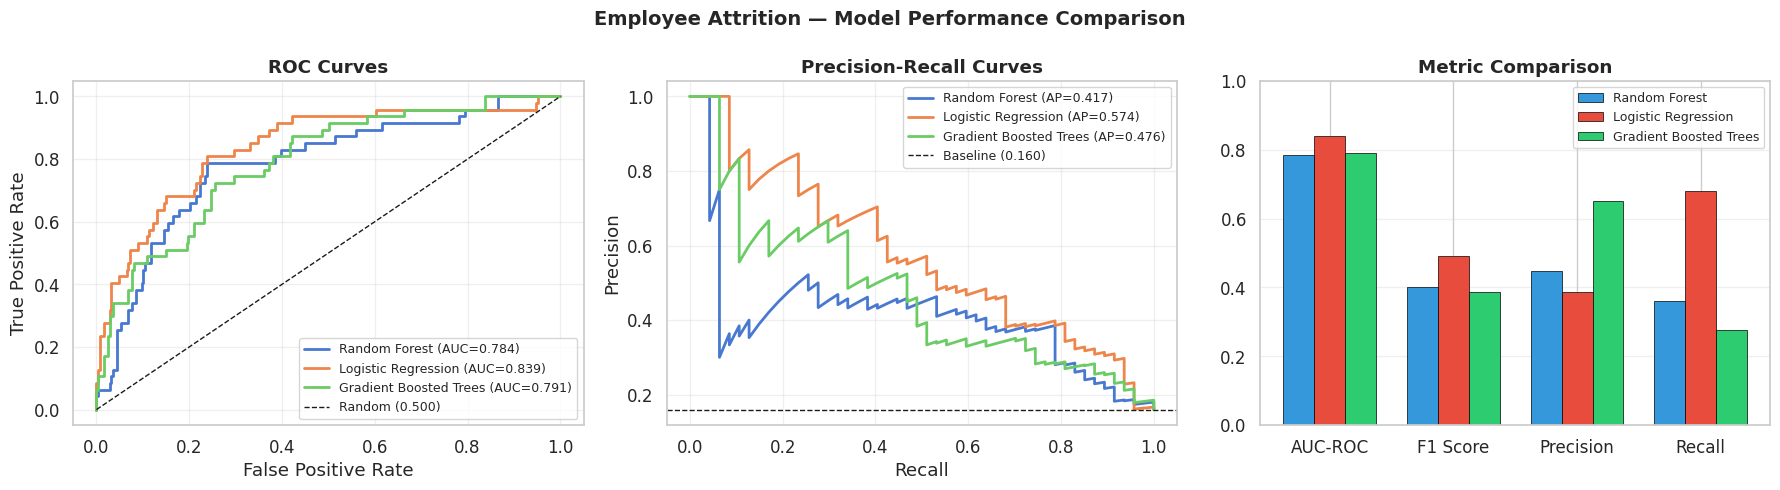

In [0]:
# --- Visual comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. ROC Curves
ax = axes[0]
for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc_roc']:.3f})", linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. Precision-Recall Curves
ax = axes[1]
for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r["y_proba"])
    ax.plot(rec, prec, label=f"{name} (AP={r['avg_precision']:.3f})", linewidth=2)
ax.axhline(y=y_test.mean(), color="k", linestyle="--", linewidth=1, label=f"Baseline ({y_test.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 3. Metric Comparison Bar Chart
ax = axes[2]
metric_names = ["AUC-ROC", "F1 Score", "Precision", "Recall"]
x = np.arange(len(metric_names))
width = 0.25
colors = ["#3498db", "#e74c3c", "#2ecc71"]

for i, (name, r) in enumerate(results.items()):
    values = [r["auc_roc"], r["f1"], r["precision"], r["recall"]]
    ax.bar(x + i * width, values, width, label=name, color=colors[i], edgecolor="black", linewidth=0.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1)
ax.set_title("Metric Comparison", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Employee Attrition — Model Performance Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Confusion Matrices

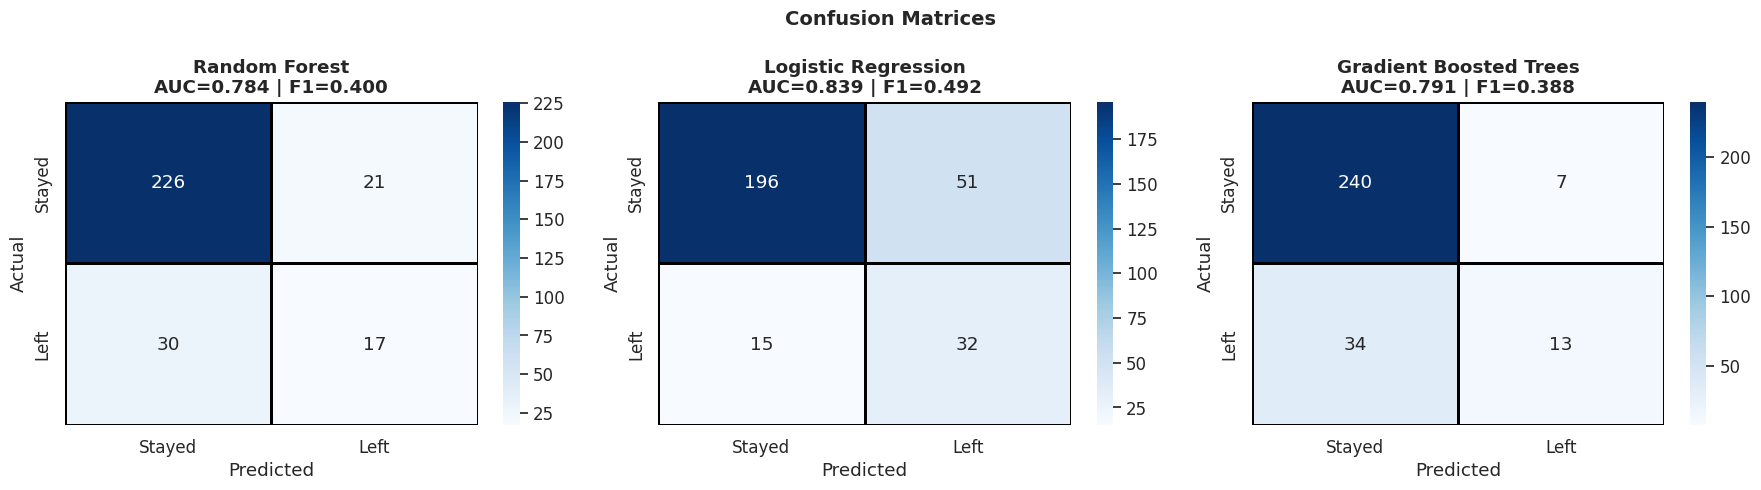


Random Forest — Classification Report
              precision    recall  f1-score   support

      Stayed       0.88      0.91      0.90       247
        Left       0.45      0.36      0.40        47

    accuracy                           0.83       294
   macro avg       0.67      0.64      0.65       294
weighted avg       0.81      0.83      0.82       294


Logistic Regression — Classification Report
              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.86       247
        Left       0.39      0.68      0.49        47

    accuracy                           0.78       294
   macro avg       0.66      0.74      0.67       294
weighted avg       0.84      0.78      0.80       294


Gradient Boosted Trees — Classification Report
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92       247
        Left       0.65      0.28      0.39        47

    accuracy                           0.86       

In [0]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, r) in enumerate(results.items()):
    ax = axes[i]
    cm = confusion_matrix(y_test, r["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Stayed", "Left"], yticklabels=["Stayed", "Left"],
        linewidths=1, linecolor="black"
    )
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
    ax.set_title(f"{name}\nAUC={r['auc_roc']:.3f} | F1={r['f1']:.3f}", fontweight="bold")

plt.suptitle("Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print detailed classification reports
for name, r in results.items():
    print(f"\n{'='*60}")
    print(f"{name} — Classification Report")
    print(f"{'='*60}")
    print(classification_report(y_test, r["y_pred"], target_names=["Stayed", "Left"]))

## 8. Feature Importance Analysis

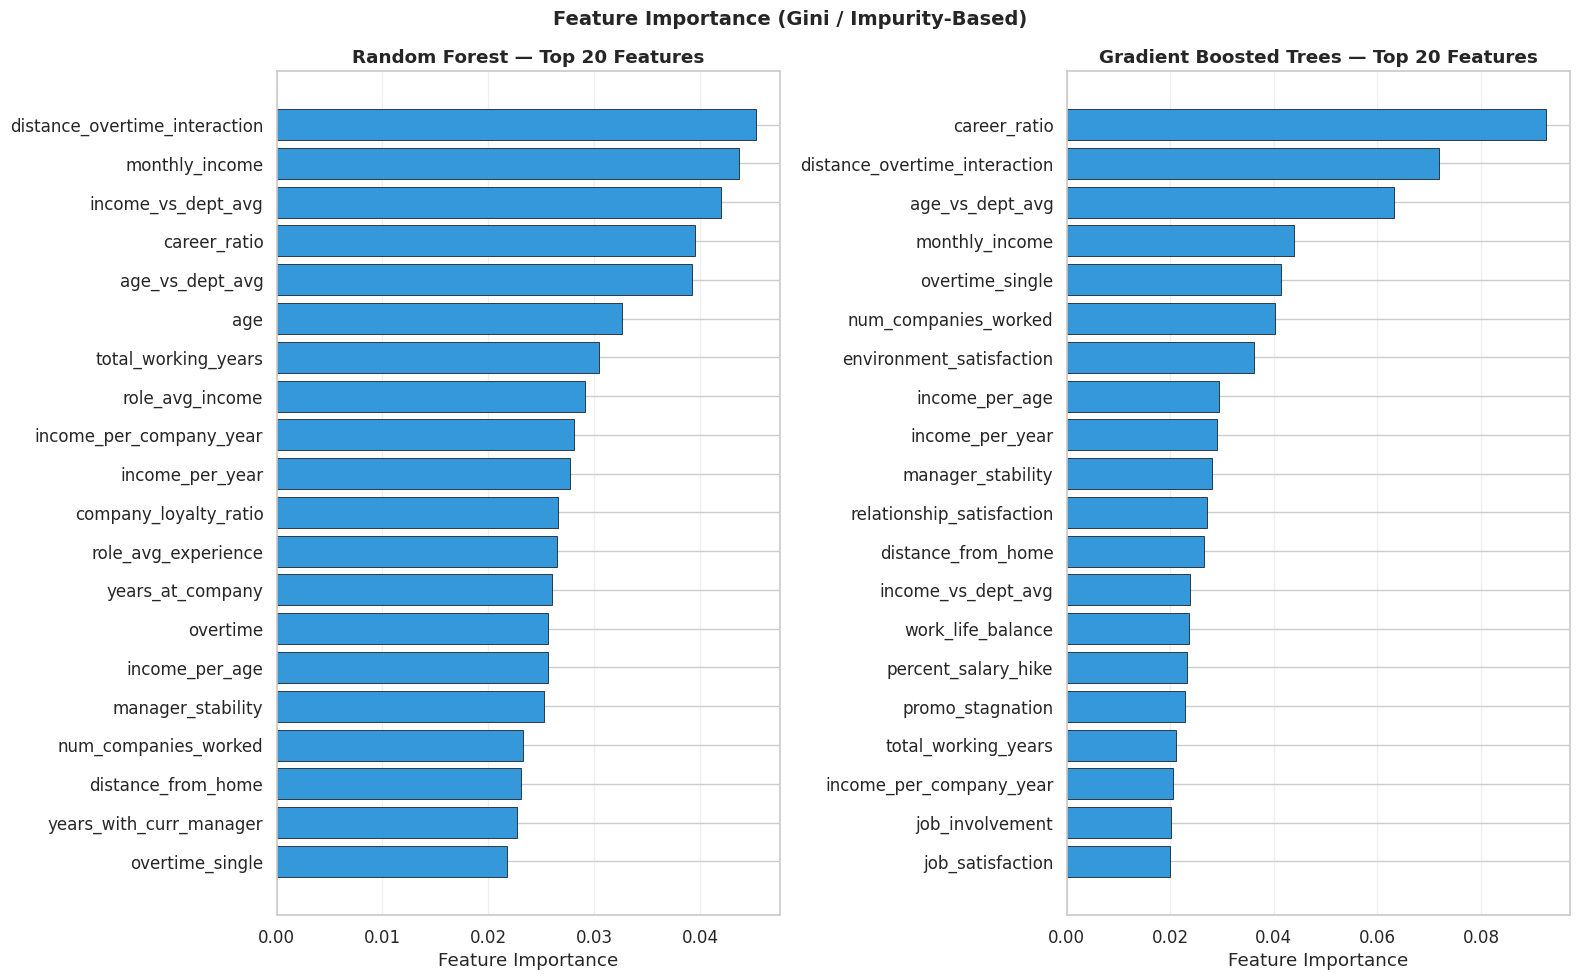

In [0]:
# --- Feature importance from tree-based models ---
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for idx, name in enumerate(["Random Forest", "Gradient Boosted Trees"]):
    ax = axes[idx]
    model = models[name]["model"]
    
    # Get feature importances
    importances = model.feature_importances_
    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": importances
    }).sort_values("importance", ascending=True)
    
    # Plot top 20
    top_20 = importance_df.tail(20)
    ax.barh(top_20["feature"], top_20["importance"], color="#3498db", edgecolor="black", linewidth=0.5)
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"{name} — Top 20 Features", fontweight="bold")
    ax.grid(True, alpha=0.3, axis="x")

plt.suptitle("Feature Importance (Gini / Impurity-Based)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

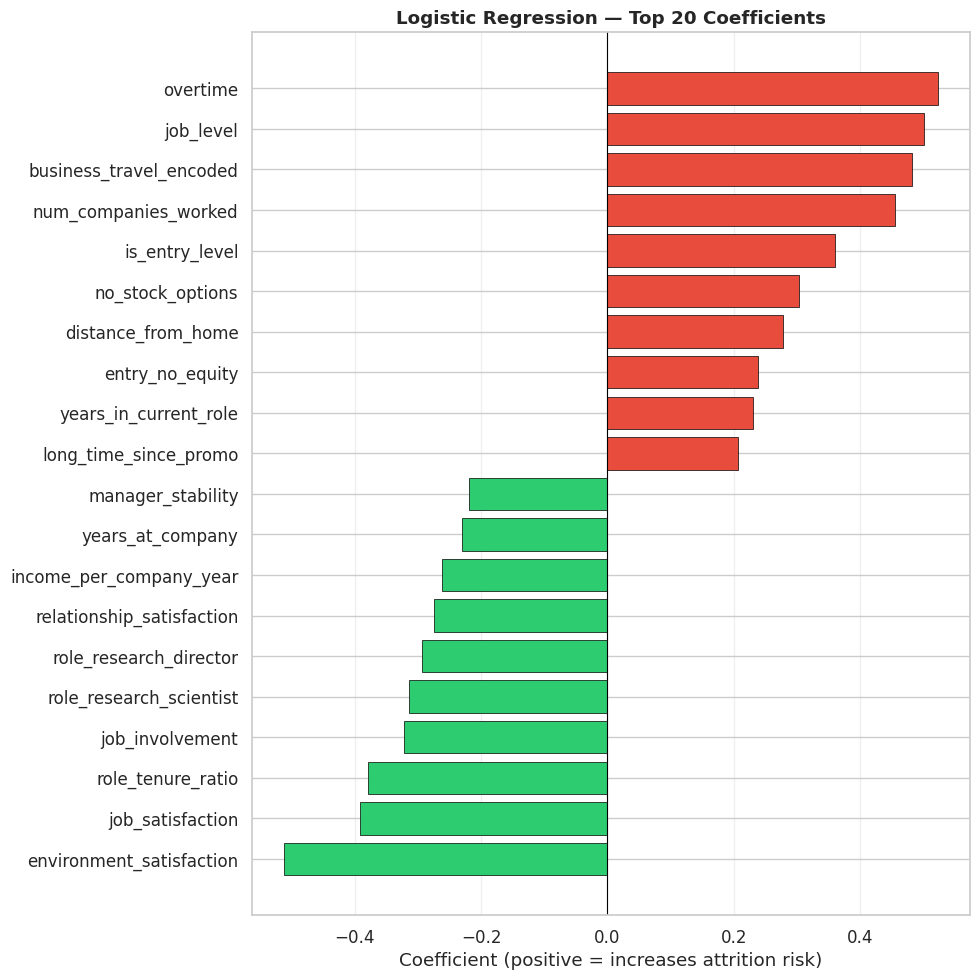


Top 10 attrition DRIVERS (positive coefficients):
  overtime                             coeff = +0.5232
  job_level                            coeff = +0.5009
  business_travel_encoded              coeff = +0.4820
  num_companies_worked                 coeff = +0.4555
  is_entry_level                       coeff = +0.3605
  no_stock_options                     coeff = +0.3036
  distance_from_home                   coeff = +0.2789
  entry_no_equity                      coeff = +0.2391
  years_in_current_role                coeff = +0.2303
  long_time_since_promo                coeff = +0.2072

Top 10 attrition PROTECTORS (negative coefficients):
  environment_satisfaction             coeff = -0.5113
  job_satisfaction                     coeff = -0.3921
  role_tenure_ratio                    coeff = -0.3796
  job_involvement                      coeff = -0.3215
  role_research_scientist              coeff = -0.3137
  role_research_director               coeff = -0.2933
  relationship_

In [0]:
# --- Logistic Regression coefficients ---
lr_model = models["Logistic Regression"]["model"]
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": lr_model.coef_[0],
    "abs_coefficient": np.abs(lr_model.coef_[0])
}).sort_values("abs_coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))

top_20_lr = coef_df.head(20).sort_values("coefficient")
colors = ["#e74c3c" if c > 0 else "#2ecc71" for c in top_20_lr["coefficient"]]
ax.barh(top_20_lr["feature"], top_20_lr["coefficient"], color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (positive = increases attrition risk)")
ax.set_title("Logistic Regression — Top 20 Coefficients", fontweight="bold")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("\nTop 10 attrition DRIVERS (positive coefficients):")
for _, row in coef_df[coef_df["coefficient"] > 0].head(10).iterrows():
    print(f"  {row['feature']:35s}  coeff = {row['coefficient']:+.4f}")

print("\nTop 10 attrition PROTECTORS (negative coefficients):")
for _, row in coef_df[coef_df["coefficient"] < 0].sort_values("coefficient").head(10).iterrows():
    print(f"  {row['feature']:35s}  coeff = {row['coefficient']:+.4f}")

## 9. Cross-Validation Comparison

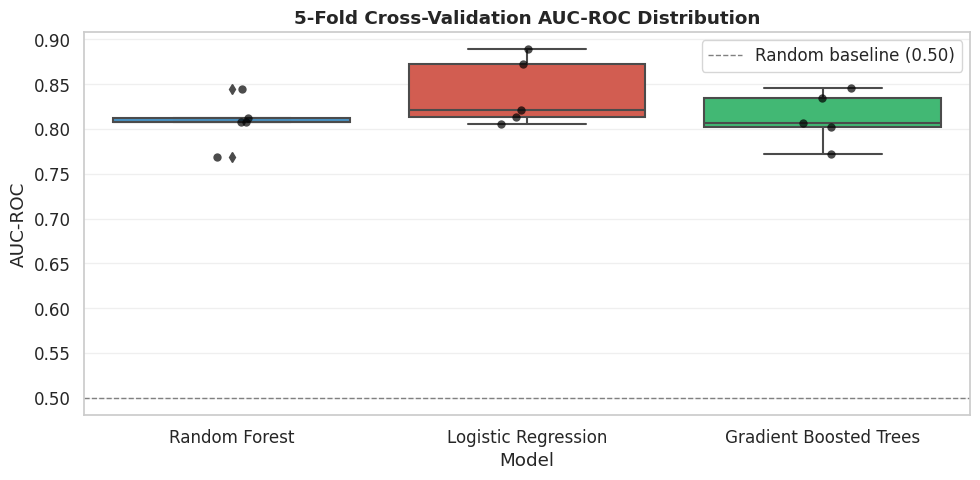


CV AUC Scores per Model:
  Random Forest                   0.8084 ± 0.0241  (folds: ['0.808', '0.808', '0.812', '0.845', '0.769'])
  Logistic Regression             0.8405 ± 0.0336  (folds: ['0.814', '0.806', '0.873', '0.889', '0.821'])
  Gradient Boosted Trees          0.8122 ± 0.0259  (folds: ['0.807', '0.772', '0.834', '0.846', '0.802'])


In [0]:
# --- CV score distributions ---
fig, ax = plt.subplots(figsize=(10, 5))

cv_data = []
for name, r in results.items():
    for score in r["cv_scores"]:
        cv_data.append({"Model": name, "AUC-ROC": score})

cv_df = pd.DataFrame(cv_data)
sns.boxplot(data=cv_df, x="Model", y="AUC-ROC", palette=["#3498db", "#e74c3c", "#2ecc71"], ax=ax)
sns.stripplot(data=cv_df, x="Model", y="AUC-ROC", color="black", size=6, alpha=0.7, ax=ax)

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline (0.50)")
ax.set_title("5-Fold Cross-Validation AUC-ROC Distribution", fontweight="bold")
ax.set_ylabel("AUC-ROC")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nCV AUC Scores per Model:")
for name, r in results.items():
    scores = r["cv_scores"]
    print(f"  {name:30s}  {scores.mean():.4f} ± {scores.std():.4f}  (folds: {[f'{s:.3f}' for s in scores]})")

## 10. Register Best Model in MLflow

In [0]:
# --- Register the best model ---
best_model_name = comparison_df.iloc[0]["Model"]
best_model_obj = models[best_model_name]["model"]
best_metrics = results[best_model_name]

# Unity Catalog requires 3-level name: catalog.schema.model_name
MODEL_REGISTRY_NAME = "workspace.gold.employee_attrition_predictor"

with mlflow.start_run(run_name=f"BEST_{best_model_name}") as run:
    # Log final model
    mlflow.log_param("model_type", best_model_name)
    mlflow.log_param("is_best", True)
    mlflow.log_param("dataset", "IBM HR Analytics")
    mlflow.log_param("n_features", len(feature_cols))
    mlflow.log_param("n_samples", len(df))
    mlflow.log_param("attrition_rate", f"{df['attrition'].mean()*100:.1f}%")
    
    mlflow.log_metric("auc_roc", best_metrics["auc_roc"])
    mlflow.log_metric("f1_score", best_metrics["f1"])
    mlflow.log_metric("precision", best_metrics["precision"])
    mlflow.log_metric("recall", best_metrics["recall"])
    mlflow.log_metric("cv_auc_mean", best_metrics["cv_auc_mean"])
    
    # Log model with signature
    from mlflow.models.signature import infer_signature
    X_sample = X_test.head(5) if not models[best_model_name]["use_scaled"] else X_test_scaled_df.head(5)
    signature = infer_signature(X_sample, best_model_obj.predict(X_sample))
    
    # Log model as artifact (always works on Community Edition)
    mlflow.sklearn.log_model(
        best_model_obj,
        artifact_path="model",
        signature=signature
    )
    
    # Log feature list
    mlflow.log_text(",".join(feature_cols), "feature_columns.txt")
    
    # Log scaler as pickle artifact (not as sklearn model — scaler has no predict())
    if models[best_model_name]["use_scaled"]:
        import joblib, tempfile, os
        with tempfile.TemporaryDirectory() as tmpdir:
            scaler_path = os.path.join(tmpdir, "scaler.joblib")
            joblib.dump(scaler, scaler_path)
            mlflow.log_artifact(scaler_path, artifact_path="scaler")
        print("Scaler saved as artifact: scaler/scaler.joblib")
    
    # Try UC registration — fails on Community Edition (S3 AccessDenied)
    registered = False
    try:
        result = mlflow.register_model(
            model_uri=f"runs:/{run.info.run_id}/model",
            name=MODEL_REGISTRY_NAME
        )
        registered = True
        print(f"Model registered in Unity Catalog: {MODEL_REGISTRY_NAME} v{result.version}")
    except Exception as reg_err:
        print(f"⚠️  UC model registration skipped (Community Edition limitation)")
        print(f"   Model is still logged as an MLflow artifact — fully usable via run ID")
    
    print(f"\nBest model: {best_model_name}")
    print(f"AUC-ROC: {best_metrics['auc_roc']:.4f}")
    print(f"F1: {best_metrics['f1']:.4f}")
    print(f"Run ID: {run.info.run_id}")
    print(f"Model URI: runs:/{run.info.run_id}/model")
    if not registered:
        print(f"\nTo load this model later:")
        print(f"  model = mlflow.sklearn.load_model('runs:/{run.info.run_id}/model')")
        print(f"  scaler = joblib.load(mlflow.artifacts.download_artifacts('runs:/{run.info.run_id}/scaler/scaler.joblib'))")

Scaler saved as artifact: scaler/scaler.joblib


Registered model 'workspace.gold.employee_attrition_predictor' already exists. Creating a new version of this model...


⚠️  UC model registration skipped (Community Edition limitation)
   Model is still logged as an MLflow artifact — fully usable via run ID

Best model: Logistic Regression
AUC-ROC: 0.8387
F1: 0.4923
Run ID: 8ec8e4bb265f48b1b5df7d1ff5e9d6b4
Model URI: runs:/8ec8e4bb265f48b1b5df7d1ff5e9d6b4/model

To load this model later:
  model = mlflow.sklearn.load_model('runs:/8ec8e4bb265f48b1b5df7d1ff5e9d6b4/model')
  scaler = joblib.load(mlflow.artifacts.download_artifacts('runs:/8ec8e4bb265f48b1b5df7d1ff5e9d6b4/scaler/scaler.joblib'))


## 11. Final Summary

In [0]:
print("=" * 80)
print("ML TRAINING SUMMARY — IBM HR EMPLOYEE ATTRITION")
print("=" * 80)

print(f"\nDATASET")
print(f"  Source:          workspace.gold.gold_ml_features")
print(f"  Rows:            {len(df):,}")
print(f"  Features:        {len(feature_cols)}")
print(f"  Target:          attrition (1=left, 0=stayed)")
print(f"  Attrition rate:  {df['attrition'].mean()*100:.1f}%")
print(f"  Train/Test:      {len(X_train)}/{len(X_test)} (80/20 stratified)")

print(f"\nMODEL RESULTS (sorted by AUC-ROC)")
print(f"  {'Model':30s} {'AUC-ROC':>8s} {'F1':>8s} {'Precision':>10s} {'Recall':>8s} {'CV AUC':>12s}")
print(f"  {'-'*80}")
for _, row in comparison_df.iterrows():
    print(f"  {row['Model']:30s} {row['AUC-ROC']:8.4f} {row['F1 Score']:8.4f} {row['Precision']:10.4f} {row['Recall']:8.4f} {row['CV AUC (mean)']:8.4f}±{row['CV AUC (std)']:.4f}")

print(f"\nBEST MODEL")
print(f"  Name:            {best_model_name}")
print(f"  AUC-ROC:         {best_metrics['auc_roc']:.4f}")
print(f"  Registered as:   {MODEL_REGISTRY_NAME}")

# Sanity check against old results
all_aucs = [r["auc_roc"] for r in results.values()]
if all(auc > 0.60 for auc in all_aucs):
    print(f"\n✅ REAL SIGNAL DETECTED — All models above 0.60 AUC")
    print(f"   Previous dataset: ~0.50 AUC (coin flip — no signal)")
    print(f"   Current dataset:  {max(all_aucs):.4f} AUC (real predictive power)")
elif all(auc < 0.55 for auc in all_aucs):
    print(f"\n❌ WARNING — All models near 0.50 AUC (possible data issue)")
else:
    print(f"\n⚠️  Mixed results — investigate feature quality")

if any(auc > 0.95 for auc in all_aucs):
    print(f"\n⚠️  WARNING: AUC > 0.95 detected — check for data leakage!")

print(f"\nNEXT STEPS")
print(f"  1. Review feature importances — validate business logic")
print(f"  2. Build Power BI dashboard from workspace.gold.gold_attrition_analytics")
print(f"  3. Use registered model for batch predictions")

print(f"\n{'='*80}")
print(f"END OF ML TRAINING")
print(f"{'='*80}")

ML TRAINING SUMMARY — IBM HR EMPLOYEE ATTRITION

DATASET
  Source:          workspace.gold.gold_ml_features
  Rows:            1,470
  Features:        75
  Target:          attrition (1=left, 0=stayed)
  Attrition rate:  16.1%
  Train/Test:      1176/294 (80/20 stratified)

MODEL RESULTS (sorted by AUC-ROC)
  Model                           AUC-ROC       F1  Precision   Recall       CV AUC
  --------------------------------------------------------------------------------
  Logistic Regression              0.8387   0.4923     0.3855   0.6809   0.8405±0.0336
  Gradient Boosted Trees           0.7906   0.3881     0.6500   0.2766   0.8122±0.0259
  Random Forest                    0.7840   0.4000     0.4474   0.3617   0.8084±0.0241

BEST MODEL
  Name:            Logistic Regression
  AUC-ROC:         0.8387
  Registered as:   workspace.gold.employee_attrition_predictor

✅ REAL SIGNAL DETECTED — All models above 0.60 AUC
   Previous dataset: ~0.50 AUC (coin flip — no signal)
   Current data